# Inputting & Importing

In [1]:
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import matplotlib
import re
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from IPython.display import Markdown, display
import random

In [2]:
%config Completer.use_jedi = False
sns.set(rc={'figure.figsize':(18,10)})
sns.set_style({'axes.facecolor':'white', 'grid.color': '.8', 'font.family':'Times New Roman'})

# Colors
cyan = '#00FFD1'
red = '#FF007D'
prussian = '#0075FF'
green = '#EEF622'
yellow = '#FFF338'
violet = '#9B65FF'
orange = '#FFA500'
blue = '#00EBFF'
vermillion = '#FF6900'
red2 = '#FF2626'
seagreen = '#28FFBF'
green2 = '#FAFF00'
navyblue = '#04009A'
darkgreen = '#206A5D'
lightgreen = '#CCF6C8'
pink = '#F35588'
mauve = '#BAABDA'
lightblue = '#1CC5DC'
mustard = '#FDB827'
deeppurple = '#723881'

color_list = [cyan,red,prussian,green,violet,orange,yellow,blue,vermillion,red2,seagreen,green2,navyblue,darkgreen,lightgreen,pink,mauve,lightblue,mustard,deeppurple]
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=color_list)

In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [4]:
def printmd(string):
    display(Markdown(string))

In [5]:
train = pd.read_csv('/kaggle/input/titanic/train.csv')
test = pd.read_csv('/kaggle/input/titanic/test.csv')

In [6]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [8]:
train.shape, test.shape

((891, 12), (418, 11))

In [9]:
# To analyse presence of any disparities and/or major factors
survived_df = train[train['Survived']==1]
deceased_df = train[train['Survived']==0]

# Data Preprocessing

## Missing Values

In [10]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

- 20% **Age** values are missing in *Train Data*, 20% in *Test Data* as well
- 0.2% **Embarked** values are missing 
- 77% **Cabin** values are missing in *Train Data* -> ***might delete later but keeping for EDA insight***
- **Fare** has just 1 missing value in *Test Data*

### Cabin

In [12]:
# train = train.drop(['Cabin'],axis=1)
# test = test.drop(['Cabin'],axis=1)

### Age

In [13]:
# 20% Age values are missing
train['Age'].isnull().sum() 

177

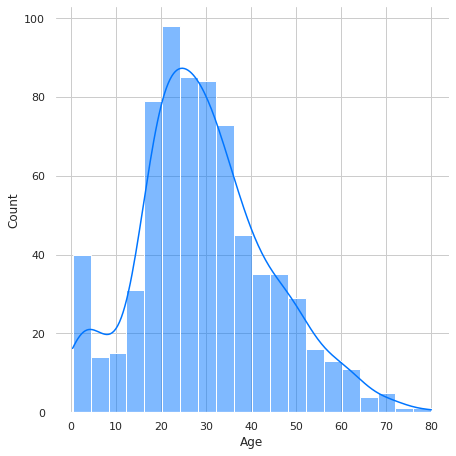

In [14]:
sns.displot(data=train['Age'],kde=True,height=6.5,color=random.choice(color_list));

Text(0.5, 0, 'Age of Passengers')

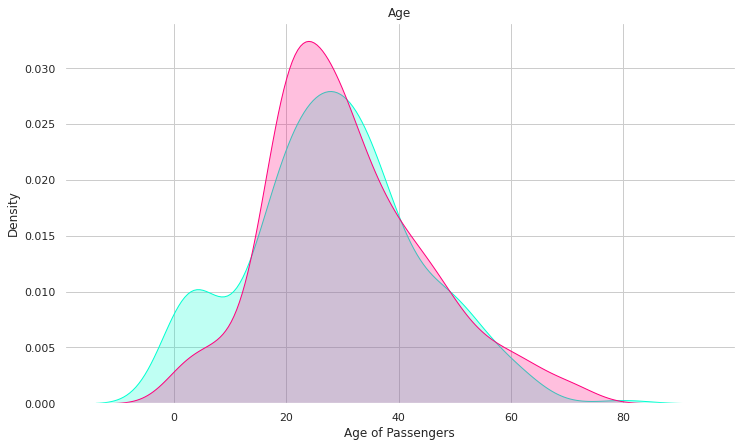

In [15]:
plt.figure(figsize=(12,7))
sns.kdeplot(survived_df['Age'],label = 'Survived', shade = True, color=cyan)
sns.kdeplot(deceased_df['Age'],label = 'Deceased', shade = True, color=red)
plt.title('Age')
plt.xlabel('Age of Passengers')

In [16]:
train['Age'] = train['Age'].fillna(train['Age'].mean())
test['Age'] = test['Age'].fillna(train['Age'].mean())

### Embarked

In [17]:
# 0.2% Embarked values are missing
train['Embarked'].isnull().sum()

2

In [18]:
train['Embarked'].value_counts()

S    644
C    168
Q     77
Name: Embarked, dtype: int64

* **S** or *Southampton* is the **Mode**

In [19]:
train['Embarked'] = train['Embarked'].fillna('S')

### Fare

In [20]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


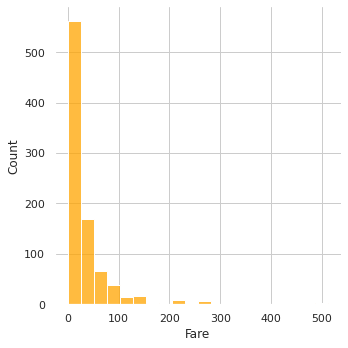

In [21]:
sns.displot(train['Fare'],bins=20,color=random.choice(color_list));

Text(0.5, 0, 'Fare of Passengers')

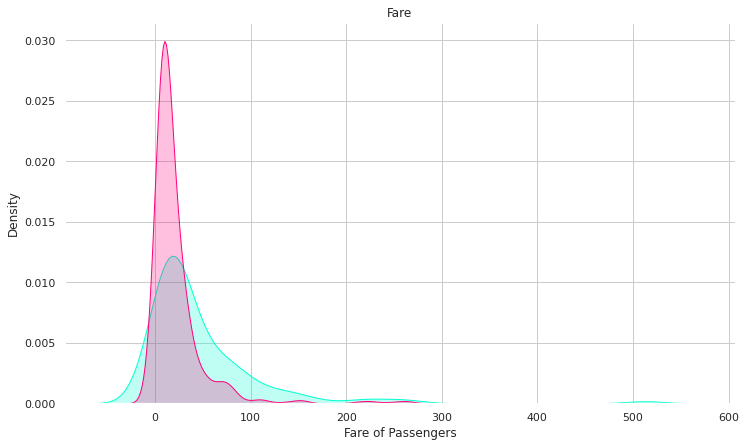

In [22]:
plt.figure(figsize=(12,7))
sns.kdeplot(survived_df['Fare'],label = 'Survived', shade = True, color=cyan)
sns.kdeplot(deceased_df['Fare'],label = 'Deceased', shade = True, color=red)
plt.title('Fare')
plt.xlabel('Fare of Passengers')

In [23]:
test['Fare'] = test['Fare'].fillna(train['Fare'].mode()[0])

In [24]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [25]:
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
dtype: int64

### Cabin

In [26]:
train['Cabin'].isnull().sum()

687

In [27]:
nonNullCabin = train[~train['Cabin'].isnull()] # non null Cabin values

In [28]:
 # Non null cabin values that Survived
len(nonNullCabin[nonNullCabin['Survived']==1])

136

In [29]:
 # Non null cabin values that didn't  # Non null cabin values that Survive
len(nonNullCabin[nonNullCabin['Survived']==0])

68

In [30]:
survived_cabins = list(nonNullCabin[nonNullCabin['Survived']==1]['Cabin'].value_counts().index)
deceased_cabins = list(nonNullCabin[nonNullCabin['Survived']==0]['Cabin'].value_counts().index)

In [31]:
# Common Cabins
c=0
for x in survived_cabins:
    if(x in deceased_cabins):
        c=c+1
print(c)

16


In [32]:
print(survived_cabins)

['B96 B98', 'E101', 'F33', 'G6', 'E25', 'C52', 'E33', 'D36', 'E8', 'D33', 'D', 'E121', 'B77', 'E24', 'D17', 'C93', 'C126', 'B49', 'B28', 'B57 B59 B63 B66', 'D35', 'C125', 'B18', 'F2', 'C23 C25 C27', 'B35', 'B5', 'B20', 'F4', 'C92', 'D20', 'E12', 'A26', 'B79', 'C83', 'E44', 'B51 B53 B55', 'E50', 'A16', 'D56', 'C101', 'B73', 'B80', 'D37', 'C85', 'D9', 'E10', 'D19', 'A20', 'E34', 'C104', 'E68', 'B42', 'A6', 'D11', 'C68', 'C65', 'C148', 'C123', 'C50', 'C47', 'A23', 'D45', 'C90', 'B58 B60', 'B101', 'C62 C64', 'F E69', 'B69', 'B3', 'D7', 'C45', 'E49', 'E17', 'C22 C26', 'B41', 'B39', 'D49', 'E40', 'B4', 'D10 D12', 'C32', 'A34', 'C103', 'B50', 'D15', 'D47', 'E67', 'C2', 'C54', 'D21', 'B22', 'D28', 'C78', 'C99', 'C106', 'A31', 'B78', 'C7', 'E36', 'C70']


In [33]:
print(deceased_cabins)

['C124', 'F G73', 'G6', 'C22 C26', 'C23 C25 C27', 'D26', 'D30', 'B71', 'E31', 'C30', 'D46', 'C83', 'E67', 'E77', 'C110', 'B51 B53 B55', 'T', 'A24', 'C118', 'C65', 'F38', 'C123', 'C78', 'C95', 'C128', 'A36', 'D50', 'C49', 'B102', 'D6', 'F2', 'C46', 'B86', 'C82', 'A7', 'B19', 'C68', 'C87', 'E46', 'B38', 'A10', 'C91', 'F G63', 'D48', 'E44', 'C111', 'A19', 'E63', 'E38', 'D', 'B94', 'C2', 'E58', 'C86', 'B30', 'A5', 'B58 B60', 'B82 B84', 'A32', 'A14', 'B22', 'B37']


### SibSp and Parch

In [34]:
train['Family'] = train['SibSp']+train['Parch']
test['Family'] = test['SibSp']+test['Parch']
# train=train.drop(['SibSp','Parch'],axis=1)
# test=test.drop(['SibSp','Parch'],axis=1)

In [35]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


# **Exploratory Data Analysis**

## **Ticket**

Here, I'll be creating new Dataframes (Test and Train each) to analyse the frequent occuring Ticket types and analayse each of those ticket groups individually

In [36]:
Ticket_temp_train = train['Ticket'].value_counts()
Ticket_temp_test = test['Ticket'].value_counts()

In [37]:
Ticket_temp_train_df = pd.DataFrame({'ticket':Ticket_temp_train.index,'freq':Ticket_temp_train.values})
Ticket_temp_test_df = pd.DataFrame({'ticket':Ticket_temp_test.index,'freq':Ticket_temp_test.values})

In [38]:
Ticket_temp_train_df.head(8)

,ticket,freq
0,CA. 2343,7
1,1601,7
2,347082,7
3,3101295,6
4,CA 2144,6
5,347088,6
6,S.O.C. 14879,5
7,382652,5


In [39]:
train.set_index('PassengerId',inplace=True)

In [40]:
train.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked', 'Family'],
      dtype='object')

In [41]:
train = train[['Survived','Name','Sex','Ticket','Age','Fare','Pclass','Embarked','Cabin','Family','SibSp', 'Parch']]

In [42]:
# This function creates a mechanism for us to parse different ranges of frequency (from the 'freq' column of the above
# newly created DataFrames) and obatin individual Tables for Analysis


def analyse_tickets(freq_to_stop_at,dataframe):
    flag = 'none'
    for i in range(0,len(Ticket_temp_train_df.iloc[:,:])): # iterating a number range
        
        ticket_name = Ticket_temp_train_df.iloc[i,0]
        ticket_freq = Ticket_temp_train_df.iloc[i,1]

        if(flag != ticket_freq and ticket_freq != freq_to_stop_at-1):
            flag=ticket_freq
            printmd('---')
            printmd('### **Ticket frequency:** **%d**'%(ticket_freq))
            print('\n')
            
    
        if (ticket_freq!=freq_to_stop_at-1):
            printmd(' #### *Ticket Name:* **%s**'%(ticket_name))
            display(dataframe.loc[dataframe['Ticket']==ticket_name])
            print('\n\n')# End of one group
        
        else:
            break
print('\n')
printmd('---')

---

#### **Among the following Table groups below, Please pay attention to:**
* How many **survived** in a group?
* Whether they're in the same family via **Family**and **Name**? (For details on family demographic, see **SipSp** and **ParCh**)
* The port they **Embarked** from
* Their **Age** demographic
* Whether they're in the same **cabin**. 

In [43]:
analyse_tickets(2,train) ## Enter frequency to stop at and dataframe to work with. For ex: (6,train)

---

### **Ticket frequency:** **7**

 #### *Ticket Name:* **CA. 2343**

,Survived,Name,Sex,Ticket,Age,Fare,Pclass,Embarked,Cabin,Family,SibSp,Parch
PassengerId,,,,,,,,,,,,
160,0,"Sage, Master. Thomas Henry",male,CA. 2343,29.699118,69.55,3,S,NaN,10,8,2
181,0,"Sage, Miss. Constance Gladys",female,CA. 2343,29.699118,69.55,3,S,NaN,10,8,2
202,0,"Sage, Mr. Frederick",male,CA. 2343,29.699118,69.55,3,S,NaN,10,8,2
325,0,"Sage, Mr. George John Jr",male,CA. 2343,29.699118,69.55,3,S,NaN,10,8,2
793,0,"Sage, Miss. Stella Anna",female,CA. 2343,29.699118,69.55,3,S,NaN,10,8,2
847,0,"Sage, Mr. Douglas Bullen",male,CA. 2343,29.699118,69.55,3,S,NaN,10,8,2
864,0,"Sage, Miss. Dorothy Edith ""Dolly""",female,CA. 2343,29.699118,69.55,3,S,NaN,10,8,2


 #### *Ticket Name:* **1601**

...

,Survived,Name,Sex,Ticket,Age,Fare,Pclass,Embarked,Cabin,Family,SibSp,Parch
PassengerId,,,,,,,,,,,,
103,0,"White, Mr. Richard Frasar",male,35281,21.0,77.2875,1,S,D26,1,0,1
125,0,"White, Mr. Percival Wayland",male,35281,54.0,77.2875,1,S,D26,1,0,1


 #### *Ticket Name:* **C.A. 2673**

,Survived,Name,Sex,Ticket,Age,Fare,Pclass,Embarked,Cabin,Family,SibSp,Parch
PassengerId,,,,,,,,,,,,
280,1,"Abbott, Mrs. Stanton (Rosa Hunt)",female,C.A. 2673,35.0,20.25,3,S,NaN,2,1,1
747,0,"Abbott, Mr. Rossmore Edward",male,C.A. 2673,16.0,20.25,3,S,NaN,2,1,1


 #### *Ticket Name:* **345764**

,Survived,Name,Sex,Ticket,Age,Fare,Pclass,Embarked,Cabin,Family,SibSp,Parch
PassengerId,,,,,,,,,,,,
39,0,"Vander Planke, Miss. Augusta Maria",female,345764,18.0,18.0,3,S,NaN,2,2,0
334,0,"Vander Planke, Mr. Leo Edmondus",male,345764,16.0,18.0,3,S,NaN,2,2,0


#### **Observations**
* Some people have more than one **cabin**. Almost all of these people belong to the 1st **Class**.
* Some people not from the same **family** are in the same **cabin**.
* Should I **age** categorize?
* There are hardly any **cabin** names for both 2nd and 3rd **Class** passengers.
* 3rd **class** passengers usually have **cabins** in F and G (for the data that is present).
* Passengers on the same **ticket** are mostly in the same **cabin** and belong to the same **class**.
* Among couples (in the same cabin) from all **classes**, it was common to see **only women** surviving in a lot of cases.

Interesting read for the side: Berth numbers were given for some passengers. Odd for lower berths and even for upper berths. [source](https://www.encyclopedia-titanica.org/cabins.html)

#### Getting Ticket prefix values

In [44]:
train.loc[1,'Ticket']

'A/5 21171'

In [45]:
train

,Survived,Name,Sex,Ticket,Age,Fare,Pclass,Embarked,Cabin,Family,SibSp,Parch
PassengerId,,,,,,,,,,,,
1,0,"Braund, Mr. Owen Harris",male,A/5 21171,22.000000,7.2500,3,S,NaN,1,1,0
2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,PC 17599,38.000000,71.2833,1,C,C85,1,1,0
3,1,"Heikkinen, Miss. Laina",female,STON/O2. 3101282,26.000000,7.9250,3,S,NaN,0,0,0
4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,113803,35.000000,53.1000,1,S,C123,1,1,0
5,0,"Allen, Mr. William Henry",male,373450,35.000000,8.0500,3,S,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
887,0,"Montvila, Rev. Juozas",male,211536,27.000000,13.0000,2,S,NaN,0,0,0
888,1,"Graham, Miss. Margaret Edith",female,112053,19.000000,30.0000,1,S,B42,0,0,0
889,0,"Johnston, Miss. Catherine Helen ""Carrie""",female,W./C. 6607,29.699118,23.4500,3,S,NaN,3,1,2


In [46]:
# c = -1
# tick_1 = {}
# for i in range(0,len(train['Ticket'])):
#     c=c+1
#     match = re.search('^[a-zA-Z]+',train.iloc[i,3])
#     if (match):
#         tick_1[c] = match.group()

In [47]:
# tick1_s = pd.Series(tick_1)
# tick1_s.head()

In [48]:
tick_prefix_train = []
for i in range(0,len(train['Ticket'])):
    match = re.search('^[a-zA-Z]+',train.iloc[i,3])
    if (match):
        tick_prefix_train.append(match.group())
    else:
        tick_prefix_train.append('Null')
        
        
tick_prefix_test = []
for i in range(0,len(test['Ticket'])):
    match = re.search('^[a-zA-Z]+',test.iloc[i,7])
    if (match):
        tick_prefix_test.append(match.group())
    else:
        tick_prefix_test.append('Null')

In [49]:
train['Ticket_prefix'] = tick_prefix_train
test['Ticket_prefix'] = tick_prefix_test

In [50]:
train.head()

,Survived,Name,Sex,Ticket,Age,Fare,Pclass,Embarked,Cabin,Family,SibSp,Parch,Ticket_prefix
PassengerId,,,,,,,,,,,,,
1,0,"Braund, Mr. Owen Harris",male,A/5 21171,22.0,7.2500,3,S,NaN,1,1,0,A
2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,PC 17599,38.0,71.2833,1,C,C85,1,1,0,PC
3,1,"Heikkinen, Miss. Laina",female,STON/O2. 3101282,26.0,7.9250,3,S,NaN,0,0,0,STON
4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,113803,35.0,53.1000,1,S,C123,1,1,0,Null
5,0,"Allen, Mr. William Henry",male,373450,35.0,8.0500,3,S,NaN,0,0,0,Null


In [51]:
Ticket_pre_df = pd.DataFrame({'prefix':train['Ticket_prefix'].value_counts().index, 'freq':train['Ticket_prefix'].value_counts().values})
Ticket_pre_df.head(15)

,prefix,freq
0,Null,661
1,PC,60
2,C,33
3,A,29
4,STON,18
5,SOTON,17
6,CA,14
7,S,14
8,SC,13
9,W,11


In [52]:
def analyse_prefix(freq_to_stop_at,dataframe):
    # booll - enter True if you want null too
    flag = 'none'
    for i in range(1,len(Ticket_pre_df)): # iterating a number range
        ticket_name = Ticket_pre_df.iloc[i,0]
        ticket_freq = Ticket_pre_df.iloc[i,1]

        if(flag != ticket_freq):
            flag=ticket_freq
            printmd('---')
            printmd('### Ticket frequency: **%d**'%(int(ticket_freq)))
            
    
        if (ticket_freq!=freq_to_stop_at-1):
            printmd(' #### *Ticket Name:* **%s**'%(ticket_name))
            display(dataframe.loc[dataframe['Ticket_prefix']==ticket_name])
            print('\n\n')# End of one number
        
        else:
            break

In [53]:
analyse_prefix(11,train) # first arg doesn't work here ##change

---

### Ticket frequency: **60**

 #### *Ticket Name:* **PC**

,Survived,Name,Sex,Ticket,Age,Fare,Pclass,Embarked,Cabin,Family,SibSp,Parch,Ticket_prefix
PassengerId,,,,,,,,,,,,,
2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,PC 17599,38.000000,71.2833,1,C,C85,1,1,0,PC
31,0,"Uruchurtu, Don. Manuel E",male,PC 17601,40.000000,27.7208,1,C,NaN,0,0,0,PC
32,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,PC 17569,29.699118,146.5208,1,C,B78,1,1,0,PC
35,0,"Meyer, Mr. Edgar Joseph",male,PC 17604,28.000000,82.1708,1,C,NaN,1,1,0,PC
53,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,PC 17572,49.000000,76.7292,1,C,D33,1,1,0,PC
65,0,"Stewart, Mr. Albert A",male,PC 17605,29.699118,27.7208,1,C,NaN,0,0,0,PC
97,0,"Goldschmidt, Mr. George B",male,PC 17754,71.000000,34.6542,1,C,A5,0,0,0,PC
98,1,"Greenfield, Mr. William Bertram",male,PC 17759,23.000000,63.3583,1,C,D10 D12,1,0,1,PC
119,0,"Baxter, Mr. Quigg Edmond",male,PC 17558,24.000000,247.5208,1,C,B58 B60,1,0,1,PC


---

...

,Survived,Name,Sex,Ticket,Age,Fare,Pclass,Embarked,Cabin,Family,SibSp,Parch,Ticket_prefix
PassengerId,,,,,,,,,,,,,
85,1,"Ilett, Miss. Bertha",female,SO/C 14885,17.0,10.5,2,S,NaN,0,0,0,SO


 #### *Ticket Name:* **SCO**

,Survived,Name,Sex,Ticket,Age,Fare,Pclass,Embarked,Cabin,Family,SibSp,Parch,Ticket_prefix
PassengerId,,,,,,,,,,,,,
240,0,"Hunt, Mr. George Henry",male,SCO/W 1585,33.0,12.275,2,S,NaN,0,0,0,SCO


 #### *Ticket Name:* **Fa**

,Survived,Name,Sex,Ticket,Age,Fare,Pclass,Embarked,Cabin,Family,SibSp,Parch,Ticket_prefix
PassengerId,,,,,,,,,,,,,
155,0,"Olsen, Mr. Ole Martin",male,Fa 265302,29.699118,7.3125,3,S,NaN,0,0,0,Fa


**Grouping all unique tickets to a common value**

In [54]:
for i in range(0,len(Ticket_temp_train_df.iloc[:,:])):
    if (Ticket_temp_train_df.loc[i,'freq'] == 1):
        train['Ticket'] = train['Ticket'].replace([ Ticket_temp_train_df.loc[i,'ticket'] ],'UniqueTicketPrefix')
        
for i in range(0,len(Ticket_temp_test_df.iloc[:,:])):
    if (Ticket_temp_test_df.loc[i,'freq'] == 1):
        test['Ticket'] = test['Ticket'].replace([ Ticket_temp_test_df.loc[i,'ticket'] ],'UniqueTicketPrefix')

In [55]:
train.head()

,Survived,Name,Sex,Ticket,Age,Fare,Pclass,Embarked,Cabin,Family,SibSp,Parch,Ticket_prefix
PassengerId,,,,,,,,,,,,,
1,0,"Braund, Mr. Owen Harris",male,UniqueTicketPrefix,22.0,7.2500,3,S,NaN,1,1,0,A
2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,UniqueTicketPrefix,38.0,71.2833,1,C,C85,1,1,0,PC
3,1,"Heikkinen, Miss. Laina",female,UniqueTicketPrefix,26.0,7.9250,3,S,NaN,0,0,0,STON
4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,113803,35.0,53.1000,1,S,C123,1,1,0,Null
5,0,"Allen, Mr. William Henry",male,UniqueTicketPrefix,35.0,8.0500,3,S,NaN,0,0,0,Null


In [56]:
train['Ticket'].value_counts()

UniqueTicketPrefix    547
1601                    7
347082                  7
CA. 2343                7
CA 2144                 6
                     ... 
250647                  2
P/PP 3381               2
248738                  2
376564                  2
243847                  2
Name: Ticket, Length: 135, dtype: int64

### Name

In [57]:
name_titles_train = []
for i in range(0,len(train['Name'])):
    title = (train.iloc[i,1].split(', ')[1]).split(' ')[0]
    name_titles_train.append(title)


name_titles_test = []
for i in range(0,len(test['Name'])):
    title = (test.iloc[i,2].split(', ')[1]).split(' ')[0]
    name_titles_test.append(title)

In [58]:
train['Title'] = name_titles_train
test['Title'] = name_titles_test

In [59]:
train = train.drop(['Name'],axis=1)
test = test.drop(['Name'],axis=1)

In [60]:
train.head()

,Survived,Sex,Ticket,Age,Fare,Pclass,Embarked,Cabin,Family,SibSp,Parch,Ticket_prefix,Title
PassengerId,,,,,,,,,,,,,
1,0,male,UniqueTicketPrefix,22.0,7.2500,3,S,NaN,1,1,0,A,Mr.
2,1,female,UniqueTicketPrefix,38.0,71.2833,1,C,C85,1,1,0,PC,Mrs.
3,1,female,UniqueTicketPrefix,26.0,7.9250,3,S,NaN,0,0,0,STON,Miss.
4,1,female,113803,35.0,53.1000,1,S,C123,1,1,0,Null,Mrs.
5,0,male,UniqueTicketPrefix,35.0,8.0500,3,S,NaN,0,0,0,Null,Mr.


In [61]:
train['Title'].value_counts()

Mr.          517
Miss.        182
Mrs.         125
Master.       40
Dr.            7
Rev.           6
Mlle.          2
Col.           2
Major.         2
Mme.           1
Don.           1
the            1
Capt.          1
Jonkheer.      1
Ms.            1
Lady.          1
Sir.           1
Name: Title, dtype: int64

<AxesSubplot:xlabel='Title', ylabel='count'>

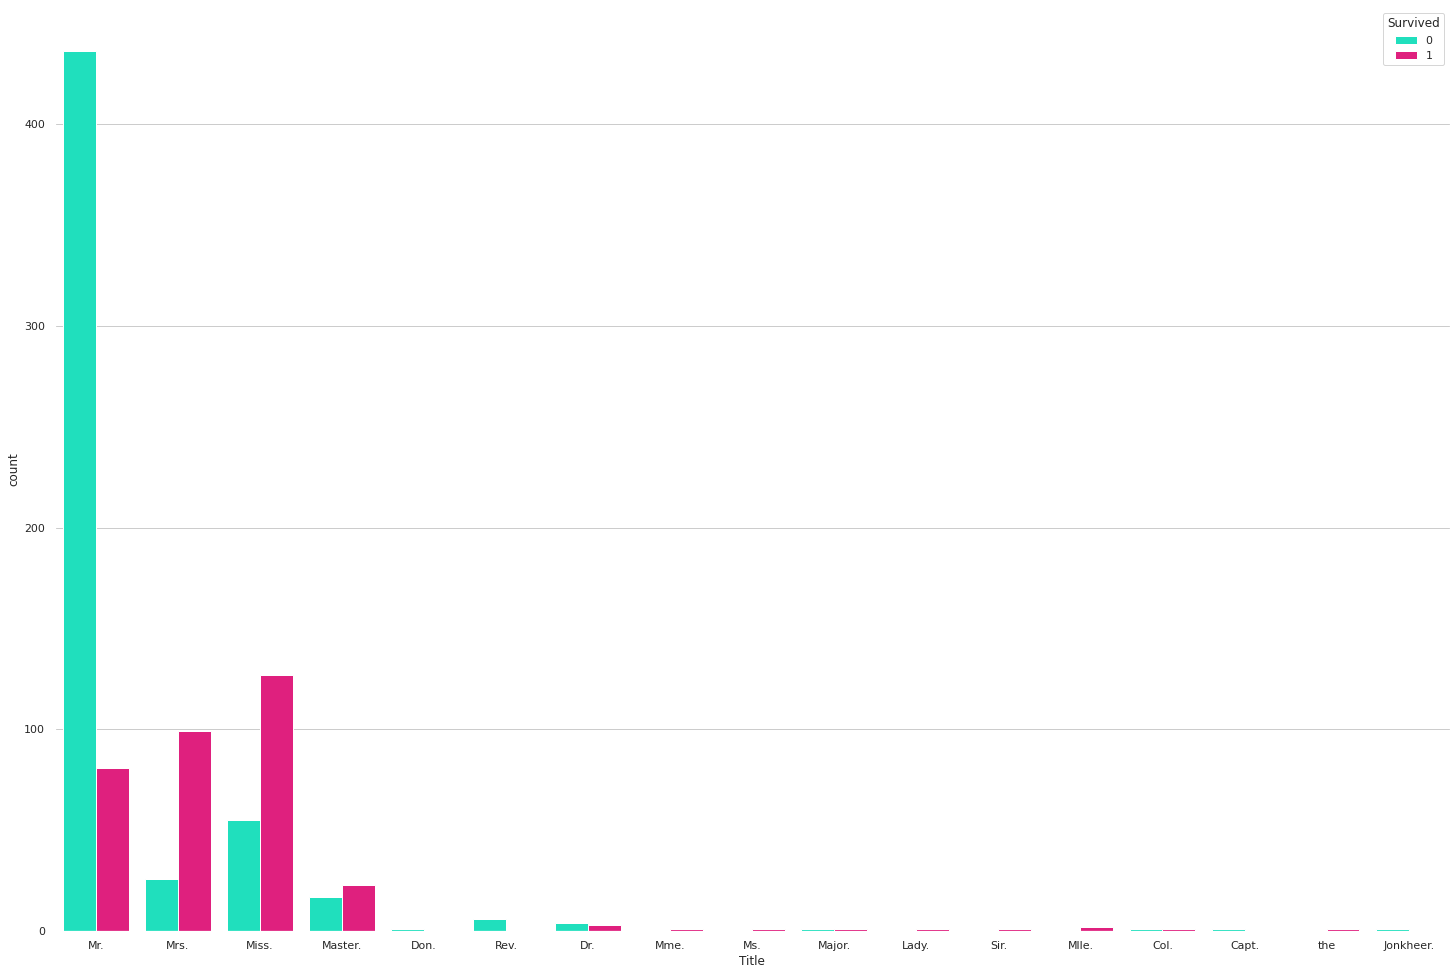

In [62]:
plt.figure(figsize=(25,17))
sns.countplot(x='Title',hue='Survived',data=train)

# Categorical Encoding

In [63]:
train.head(7)

,Survived,Sex,Ticket,Age,Fare,Pclass,Embarked,Cabin,Family,SibSp,Parch,Ticket_prefix,Title
PassengerId,,,,,,,,,,,,,
1,0,male,UniqueTicketPrefix,22.000000,7.2500,3,S,NaN,1,1,0,A,Mr.
2,1,female,UniqueTicketPrefix,38.000000,71.2833,1,C,C85,1,1,0,PC,Mrs.
3,1,female,UniqueTicketPrefix,26.000000,7.9250,3,S,NaN,0,0,0,STON,Miss.
4,1,female,113803,35.000000,53.1000,1,S,C123,1,1,0,Null,Mrs.
5,0,male,UniqueTicketPrefix,35.000000,8.0500,3,S,NaN,0,0,0,Null,Mr.
6,0,male,UniqueTicketPrefix,29.699118,8.4583,3,Q,NaN,0,0,0,Null,Mr.
7,0,male,UniqueTicketPrefix,54.000000,51.8625,1,S,E46,0,0,0,Null,Mr.


In [64]:
# Categories

for i in (1,2,5,6,7,11,12):
    c = train.columns[i]
    printmd('### %s'%(c))
    display(train[c].value_counts())
    print(' ')

### Sex

male      577
female    314
Name: Sex, dtype: int64

### Ticket

UniqueTicketPrefix    547
1601                    7
347082                  7
CA. 2343                7
CA 2144                 6
                     ... 
250647                  2
P/PP 3381               2
248738                  2
376564                  2
243847                  2
Name: Ticket, Length: 135, dtype: int64

### Pclass

...

C23 C25 C27    4
B96 B98        4
G6             4
D              3
F33            3
              ..
C30            1
C7             1
C82            1
C90            1
B41            1
Name: Cabin, Length: 147, dtype: int64

### Ticket_prefix

Null     661
PC        60
C         33
A         29
STON      18
SOTON     17
CA        14
S         14
SC        13
W         11
F          6
LINE       4
PP         3
WE         2
P          2
SW         1
SO         1
SCO        1
Fa         1
Name: Ticket_prefix, dtype: int64

### Title

Mr.          517
Miss.        182
Mrs.         125
Master.       40
Dr.            7
Rev.           6
Mlle.          2
Col.           2
Major.         2
Mme.           1
Don.           1
the            1
Capt.          1
Jonkheer.      1
Ms.            1
Lady.          1
Sir.           1
Name: Title, dtype: int64

## Mean Encoding for **Ticket**, **Ticket_prefix** and **Title** columns

In [65]:
def Mean_Encoding(column_name):
    new_smooth_name = column_name+'_smean_encod'
    
    mean = train['Survived'].mean()
    agg= train.groupby(column_name)['Survived'].agg(['count','mean'])
    counts = agg['count']
    means = agg['mean']
    weight = 100
    smooth = (counts*means + weight*mean)/(counts+weight)
    
    train.loc[:,new_smooth_name] = train[column_name].map(smooth)
    test.loc[:,new_smooth_name] = test[column_name].map(smooth)    
    

In [66]:
Mean_Encoding('Ticket')

In [67]:
Mean_Encoding('Ticket_prefix')

In [68]:
Mean_Encoding('Title')

In [69]:
test.isnull().sum()

PassengerId                    0
Pclass                         0
Sex                            0
Age                            0
SibSp                          0
Parch                          0
Ticket                         0
Fare                           0
Cabin                        327
Embarked                       0
Family                         0
Ticket_prefix                  0
Title                          0
Ticket_smean_encod            59
Ticket_prefix_smean_encod      3
Title_smean_encod              1
dtype: int64

This means, there are new uniue values in the test dataset which weren't mapped to the smooth values we have here

### Missing values after mean Encoding

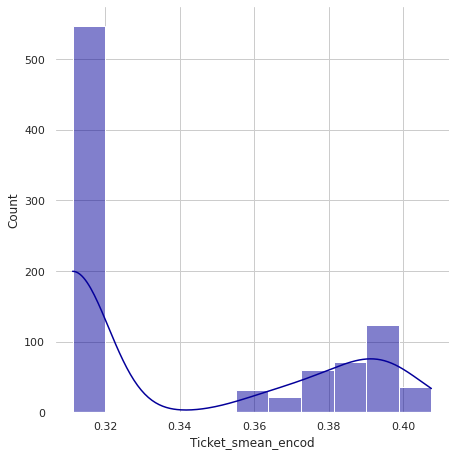

In [70]:
sns.displot(data=train['Ticket_smean_encod'],kde=True,height=6.5,color=random.choice(color_list));

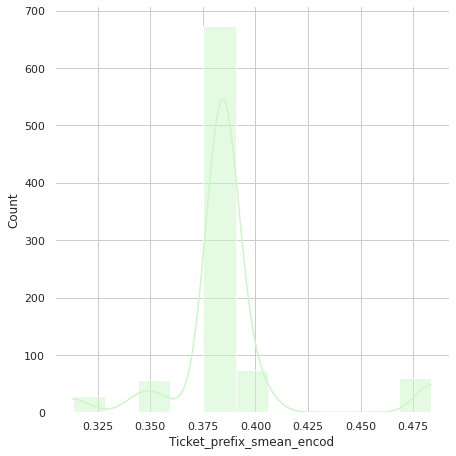

In [71]:
sns.displot(data=train['Ticket_prefix_smean_encod'],kde=True,height=6.5,color=random.choice(color_list));

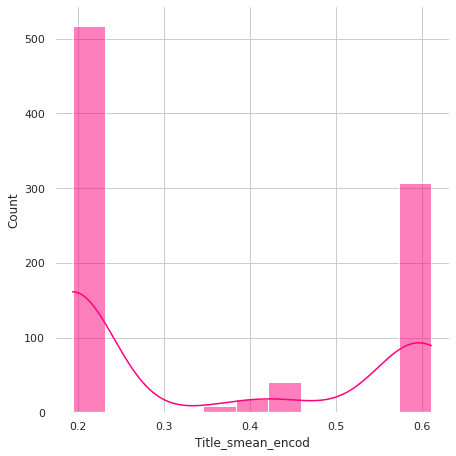

In [72]:
sns.displot(data=train['Title_smean_encod'],kde=True,height=6.5,color=random.choice(color_list));

In [73]:
test['Ticket_smean_encod'] = test['Ticket_smean_encod'].fillna(train['Ticket_smean_encod'].mean())
test['Ticket_prefix_smean_encod'] = test['Ticket_prefix_smean_encod'].fillna(train['Ticket_prefix_smean_encod'].mean())
test['Title_smean_encod'] = test['Title_smean_encod'].fillna(train['Title_smean_encod'].mean())

In [74]:
test.isnull().sum()

PassengerId                    0
Pclass                         0
Sex                            0
Age                            0
SibSp                          0
Parch                          0
Ticket                         0
Fare                           0
Cabin                        327
Embarked                       0
Family                         0
Ticket_prefix                  0
Title                          0
Ticket_smean_encod             0
Ticket_prefix_smean_encod      0
Title_smean_encod              0
dtype: int64

## One Hot Encoding for **Sex**, **Embarked** and **Pclass** columns

In [75]:
# Sex

train['Sex_female'] = pd.get_dummies(train.Sex, prefix='Sex')['Sex_female']
train['Sex_male'] = pd.get_dummies(train.Sex, prefix='Sex')['Sex_male']
test['Sex_female'] = pd.get_dummies(test.Sex, prefix='Sex')['Sex_female']
test['Sex_male'] = pd.get_dummies(test.Sex, prefix='Sex')['Sex_male']

In [76]:
# Pclass

train['Pclass_1'] = pd.get_dummies(train.Pclass, prefix='Pclass')['Pclass_1']
train['Pclass_2'] = pd.get_dummies(train.Pclass, prefix='Pclass')['Pclass_2']
train['Pclass_3'] = pd.get_dummies(train.Pclass, prefix='Pclass')['Pclass_3']

test['Pclass_1'] = pd.get_dummies(test.Pclass, prefix='Pclass')['Pclass_1']
test['Pclass_2'] = pd.get_dummies(test.Pclass, prefix='Pclass')['Pclass_2']
test['Pclass_3'] = pd.get_dummies(test.Pclass, prefix='Pclass')['Pclass_3']

In [77]:
# Embarked

train['Embarked_C'] = pd.get_dummies(train.Embarked, prefix='Embarked')['Embarked_C']
train['Embarked_Q'] = pd.get_dummies(train.Embarked, prefix='Embarked')['Embarked_Q']
train['Embarked_S'] = pd.get_dummies(train.Embarked, prefix='Embarked')['Embarked_S']

test['Embarked_C'] = pd.get_dummies(test.Embarked, prefix='Embarked')['Embarked_C']
test['Embarked_Q'] = pd.get_dummies(test.Embarked, prefix='Embarked')['Embarked_Q']
test['Embarked_S'] = pd.get_dummies(test.Embarked, prefix='Embarked')['Embarked_S']

In [78]:
train.columns

Index(['Survived', 'Sex', 'Ticket', 'Age', 'Fare', 'Pclass', 'Embarked',
       'Cabin', 'Family', 'SibSp', 'Parch', 'Ticket_prefix', 'Title',
       'Ticket_smean_encod', 'Ticket_prefix_smean_encod', 'Title_smean_encod',
       'Sex_female', 'Sex_male', 'Pclass_1', 'Pclass_2', 'Pclass_3',
       'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [79]:
df_train = train[['Age','Fare','Ticket_prefix_smean_encod','Sex_female','Pclass_1','Pclass_2','Embarked_C',
       'Embarked_Q','Survived']] # omitted extra dummy variables
df_test = test[['Age','Fare','Ticket_prefix_smean_encod','Sex_female','Pclass_1','Pclass_2','Embarked_C',
       'Embarked_Q']] # omitted extra dummy variables

# Correlation

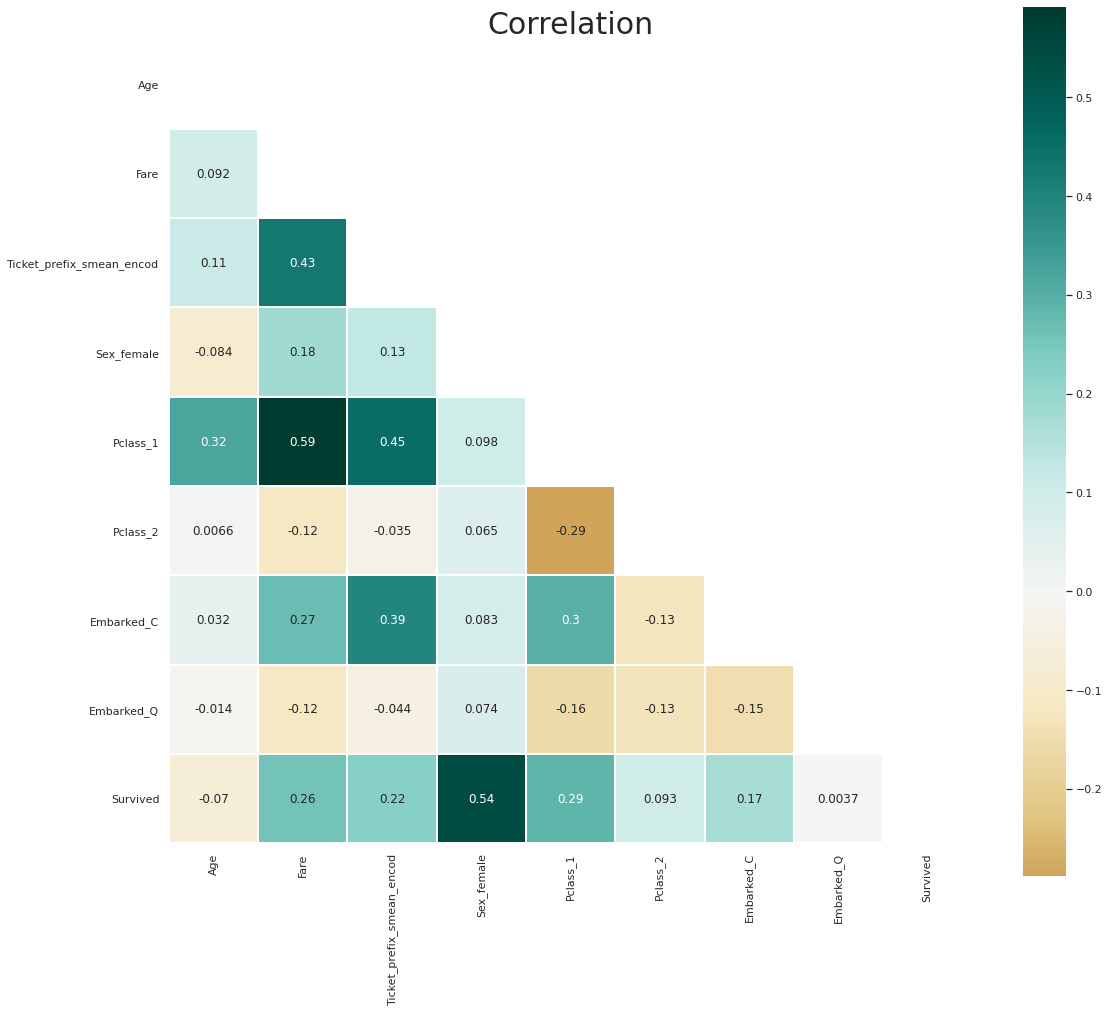

In [80]:
fig, ax = plt.subplots(figsize=(18,16)) 
my_c = sns.diverging_palette(20, 220, as_cmap=True)
mask = np.triu(df_train.corr())
sns.heatmap(df_train.corr(),cmap='BrBG',linewidths=1.5,ax=ax,annot=True,center=0,square=True,mask=mask)
plt.title('Correlation',fontsize=30);

In [81]:
train.head()

,Survived,Sex,Ticket,Age,Fare,Pclass,Embarked,Cabin,Family,SibSp,...,Ticket_prefix_smean_encod,Title_smean_encod,Sex_female,Sex_male,Pclass_1,Pclass_2,Pclass_3,Embarked_C,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,,,,,,,,,,,
1,0,male,UniqueTicketPrefix,22.0,7.2500,3,S,NaN,1,1,...,0.313053,0.193491,0,1,0,0,1,0,0,1
2,1,female,UniqueTicketPrefix,38.0,71.2833,1,C,C85,1,1,...,0.483649,0.610595,1,0,1,0,0,1,0,0
3,1,female,UniqueTicketPrefix,26.0,7.9250,3,S,NaN,0,0,...,0.393083,0.586468,1,0,0,0,1,0,0,1
4,1,female,113803,35.0,53.1000,1,S,C123,1,1,...,0.384210,0.610595,1,0,1,0,0,0,0,1
5,0,male,UniqueTicketPrefix,35.0,8.0500,3,S,NaN,0,0,...,0.384210,0.193491,0,1,0,0,1,0,0,1
